In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Cleaned/finaldataset.csv')
df.head()

,date,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,1954-07-01,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,1954-08-01,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,1954-09-01,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,1954-10-01,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,1954-11-01,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [3]:
df.drop(columns=['date'], inplace=True)
df.head()

,ConsumerPriceIndexAllItems,FEDRates,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
0,0.0,0.80,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,5.8
1,0.0,1.22,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.0
2,0.0,1.07,390.996,1.457976,5.014653,2880.482,17701.0,2923.974918,6.1
3,0.0,0.85,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.7
4,0.0,0.83,399.734,1.457976,5.014653,2936.852,17960.0,2941.999753,5.3


In [4]:
median_value = df['FEDRates'].median()
df['FEDRates_Binary'] = df['FEDRates'].apply(lambda x: 0 if x <= median_value else 1)

In [5]:
X = df.drop(columns=['FEDRates', 'FEDRates_Binary'])
y = df['FEDRates_Binary']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [7]:
X_train.head()

,ConsumerPriceIndexAllItems,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
499,0.323834,7868.468,2.931204,2.618961,11614.418,43259.0,11674.216233,5.5
576,0.111173,10984.040,1.586032,2.245055,14519.633,50362.0,14813.102099,5.8
329,0.320171,3280.818,10.334715,5.014653,7410.768,32095.0,7666.119260,8.5
189,0.785340,1067.375,5.838255,5.014653,5308.164,25929.0,5347.137427,4.6
275,0.663350,2055.909,6.501684,5.014653,6654.466,30254.0,6701.716063,7.2


In [8]:
X_test.head()

,ConsumerPriceIndexAllItems,GDP,InflationConsumerPrice,MedianConsumerPriceIndex,RealGDP,RealGDPPerCapita,RealPotentialGDP,UnemployemenrRate
743,0.328437,18711.702,1.261583,2.103390,19062.709,58787.0,19375.150668,4.9
308,1.520913,2789.842,13.549202,5.014653,7341.557,32377.0,7347.149549,6.3
443,0.294985,6126.862,4.234964,2.901936,10029.510,39632.0,10346.859533,6.9
444,0.147059,6205.937,4.234964,4.442030,10080.195,39691.0,10409.384121,6.8
566,0.450704,10598.020,2.826171,2.782508,14214.516,49774.0,14421.269311,5.0


In [22]:
y_train.head()

499    1
576    0
329    1
189    1
275    1
Name: FEDRates_Binary, dtype: int64

In [23]:
y_test.head()

743    0
308    1
443    1
444    1
566    0
Name: FEDRates_Binary, dtype: int64

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_linear = SVC(kernel='linear', C=1.0, gamma='scale', random_state=42)
svm_poly = SVC(kernel='poly', degree=2, C=1.0, gamma='scale', random_state=42)

In [11]:
models = {
    "SVM - RBF Kernel": svm_rbf,
    "SVM - Linear Kernel": svm_linear,
    "SVM - Polynomial Kernel (Degree=2)": svm_poly
}
results = {}

In [12]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    results[name] = {"accuracy": acc, "confusion_matrix": cm}

In [13]:
for name, res in results.items():
    print(f"{name}: Accuracy = {res['accuracy']:.4f}")

SVM - RBF Kernel: Accuracy = 0.9176
SVM - Linear Kernel: Accuracy = 0.8118
SVM - Polynomial Kernel (Degree=2): Accuracy = 0.8353


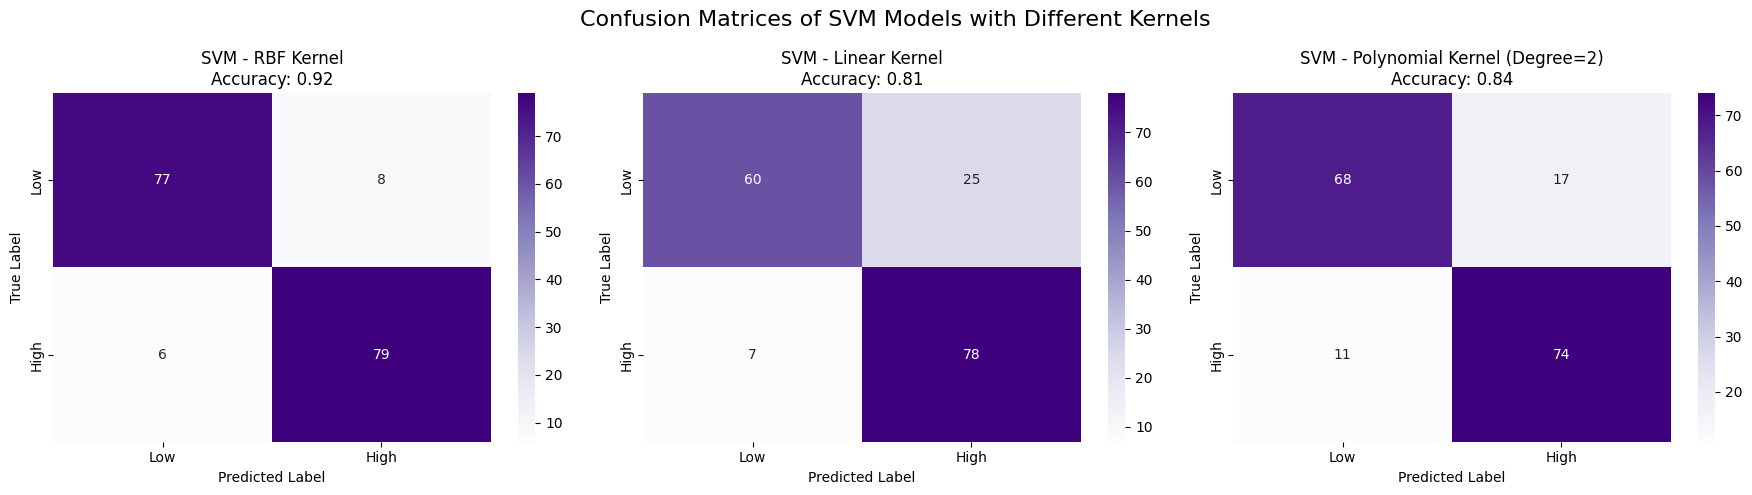

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res["confusion_matrix"], annot=True, fmt='d', cmap='Purples', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(f"{name}\nAccuracy: {res['accuracy']:.2f}")
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle("Confusion Matrices of SVM Models with Different Kernels", fontsize=16)
plt.tight_layout()
plt.show()

In [15]:
metrics_results = {}

In [16]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    metrics_results[name] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

In [17]:
metrics_df = pd.DataFrame(metrics_results).T  # transpose for better plotting
print(metrics_df)

                                    Accuracy  Precision    Recall  F1-Score
SVM - RBF Kernel                    0.917647   0.908046  0.929412  0.918605
SVM - Linear Kernel                 0.811765   0.757282  0.917647  0.829787
SVM - Polynomial Kernel (Degree=2)  0.835294   0.813187  0.870588  0.840909


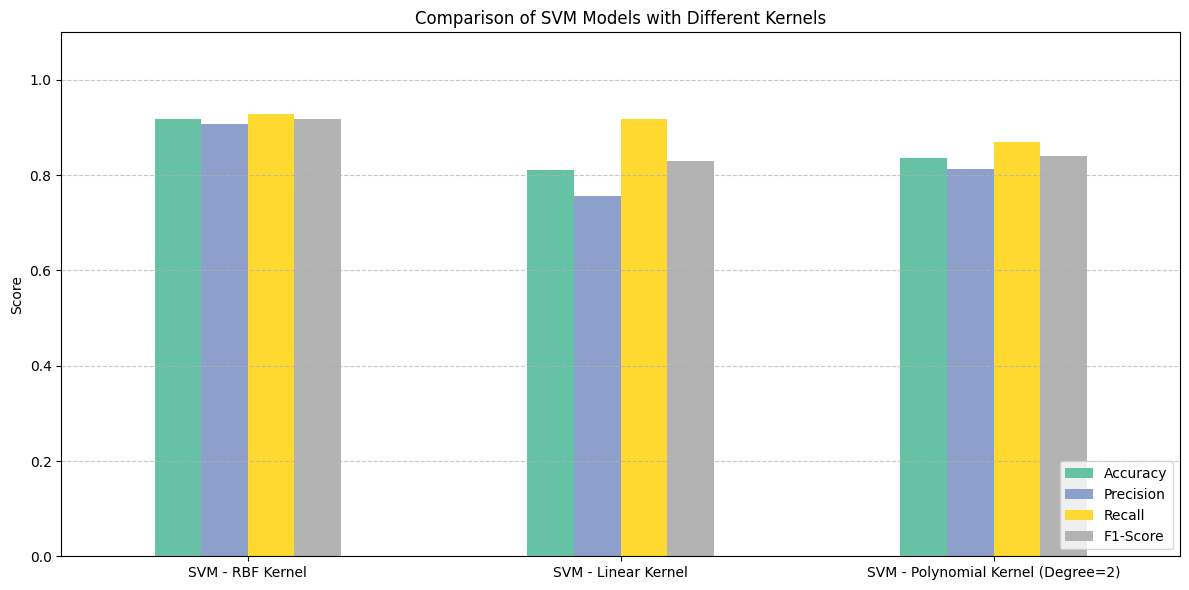

In [18]:
metrics_df.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Comparison of SVM Models with Different Kernels')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=360, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [19]:
cost_values = [0.1, 1, 10, 100]
cost_results = []

In [20]:
for kernel in ['rbf', 'linear', 'poly']:
    for C_value in cost_values:
        if kernel == 'poly':
            model = SVC(kernel=kernel, degree=2, C=C_value, gamma='scale', random_state=42)
        else:
            model = SVC(kernel=kernel, C=C_value, gamma='scale', random_state=42)
        
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)
        
        cost_results.append({
            'Kernel': kernel,
            'Cost (C)': C_value,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

# Convert to DataFrame
cost_df = pd.DataFrame(cost_results)

# Display
print(cost_df)

    Kernel  Cost (C)  Accuracy  Precision    Recall  F1-Score
0      rbf       0.1  0.847059   0.855422  0.835294  0.845238
1      rbf       1.0  0.917647   0.908046  0.929412  0.918605
2      rbf      10.0  0.952941   0.923077  0.988235  0.954545
3      rbf     100.0  0.935294   0.911111  0.964706  0.937143
4   linear       0.1  0.811765   0.791209  0.847059  0.818182
5   linear       1.0  0.811765   0.757282  0.917647  0.829787
6   linear      10.0  0.894118   0.838384  0.976471  0.902174
7   linear     100.0  0.888235   0.866667  0.917647  0.891429
8     poly       0.1  0.788235   0.781609  0.800000  0.790698
9     poly       1.0  0.835294   0.813187  0.870588  0.840909
10    poly      10.0  0.864706   0.852273  0.882353  0.867052
11    poly     100.0  0.888235   0.875000  0.905882  0.890173


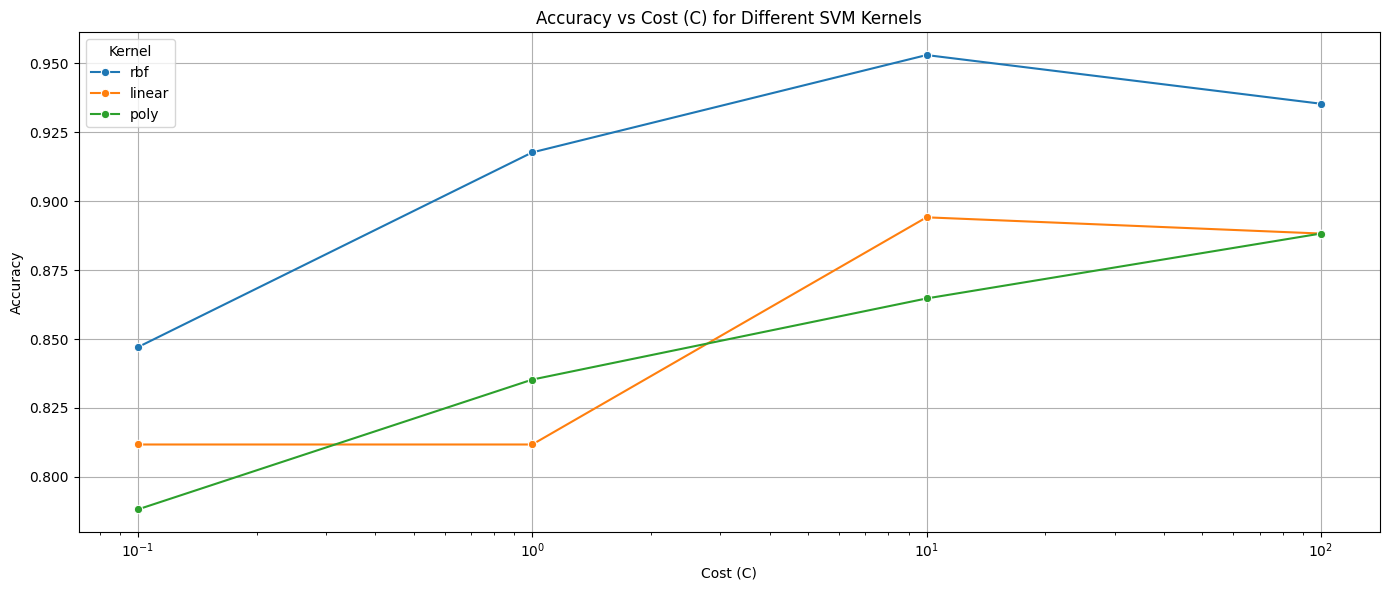

In [21]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=cost_df, x='Cost (C)', y='Accuracy', hue='Kernel', marker='o')
plt.title('Accuracy vs Cost (C) for Different SVM Kernels')
plt.xscale('log')  # Cost values are usually better visualized in log scale
plt.xlabel('Cost (C)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(title='Kernel')
plt.tight_layout()
plt.show()